In [1]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = 'cuda' if torch.cuda.is_available() else 'cpu'
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.plots import plot_training_metrics
from utils.train import evaluate_model
from utils.summary import get_model_stats
from utils.losses import Accuracy, MIoU, MulticlassF1Score, PrecisionRecallF1

# Helper Funcs

In [22]:
def get_predictions(model, dataloader, device='cpu'):
    model.to(device)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)  # ✅ Assign back to variable
            lbls = lbls.to(device)      # ✅ Assign back to variable
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    return np.array(preds), np.array(labels)


# MNIST

In [ ]:
from data.mnist import get_mnist_pipeline
import models.baseline as mlp


_, _, test_loader = get_mnist_pipeline(batch_size=128, val_split=0)
sample_x, sample_y = next(iter(test_loader))

# can plot some images
def show_images():
    pass

In [ ]:
teacher = mlp.mnist1200().to(device)
smaller = mlp.mnist800().to(device)
student = mlp.mnist800().to(device)
trnsfr1 = mlp.mnist800().to(device)
trnsfr2 = mlp.mnist800().to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("MNIST1200 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("MNIST800 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/mnist_teacher.pth'
smaller_path = '../models/final_weights/mnist_smaller.pth'
student_path = '../models/final_weights/mnist_student_t5.pth'
trnsfr1_path = '../models/final_weights/mnist_transfer_t3_a70_0.pth'
trnsfr2_path = '../models/final_weights/mnist_reference.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
trnsfr1_state = torch.load(trnsfr1_path, map_location=device)
trnsfr2_state = torch.load(trnsfr2_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])
trnsfr1.load_state_dict(trnsfr1_state['state_dict'])
trnsfr2.load_state_dict(trnsfr2_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
smaller_test_acc = evaluate_model(test_loader, smaller, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
trnsfr1_test_acc = evaluate_model(test_loader, trnsfr1, Accuracy(), device)
trnsfr2_test_acc = evaluate_model(test_loader, trnsfr2, Accuracy(), device)

print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Smaller: Val Accuracy: {smaller_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")
print(f"trnsfr1: Val Accuracy: {trnsfr1_state['accuracy']:.4f}")
print(f"trnsfr2: Val Accuracy: {trnsfr2_state['accuracy']:.4f}")

print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Smaller: Test Accuracy: {smaller_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")
print(f"trnsfr1: Test Accuracy: {trnsfr1_test_acc:.4f}")
print(f"trnsfr2: Test Accuracy: {trnsfr2_test_acc:.4f}")

MNIST1200 stats:
flops: 490598400
params: 3836410
MNIST800 stats:
flops: 245145600
params: 1917610
evaluating...: 100%|██████████| 79/79 [00:02<00:00, 32.43it/s]
Teacher: Val Accuracy: 0.9908
Smaller: Val Accuracy: 0.9873
Student: Val Accuracy: 0.9886
trnsfr1: Val Accuracy: 0.9906
trnsfr2: Val Accuracy: 0.9911
Teacher: Test Accuracy: 0.9908
Smaller: Test Accuracy: 0.9873
Student: Test Accuracy: 0.9886
trnsfr1: Test Accuracy: 0.9725
trnsfr2: Test Accuracy: 0.8935


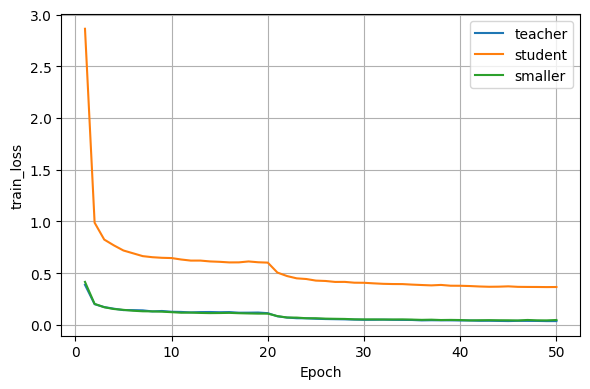

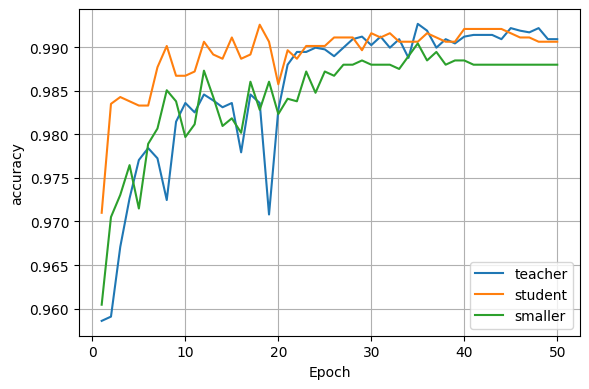

In [ ]:
models = ['teacher', 'student', 'smaller']
collection = []
with open(os.path.join(project_dir, 'data/states/mnist_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_student_t5.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_smaller.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

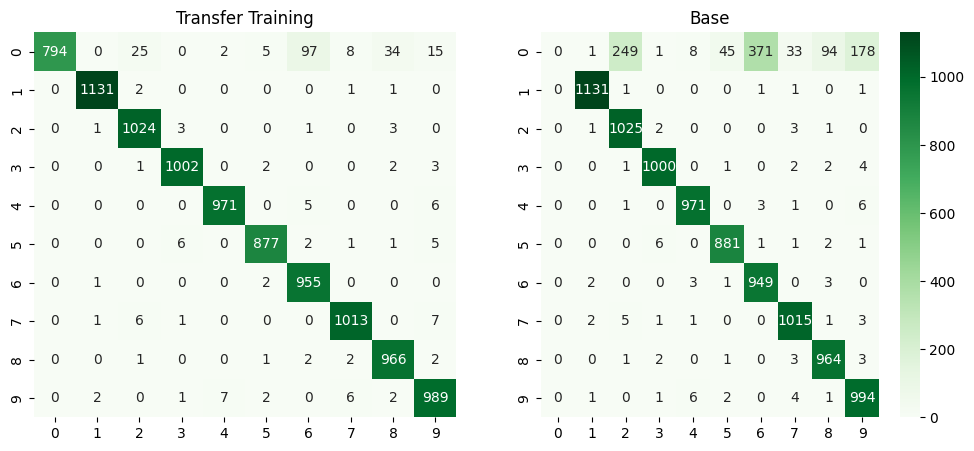

In [34]:
# Get predictions for both models
preds_transfer, labels = get_predictions(trnsfr1, test_loader, device)
preds_original, _ = get_predictions(trnsfr2, test_loader, device)

# Compute confusion matrices
cm_transfer = confusion_matrix(labels, preds_transfer)
cm_original = confusion_matrix(labels, preds_original)

# Compute min/max values for consistent color scaling
vmin = min(cm_transfer.min(), cm_original.min())
vmax = max(cm_transfer.max(), cm_original.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1]})  # Same width ratio

# Left heatmap (No color bar)
sns.heatmap(cm_transfer, annot=True, fmt="d", cmap="Greens", ax=axes[0], vmin=vmin, vmax=vmax, cbar=False)
axes[0].set_title("Transfer Training")

# Right heatmap (With color bar)
sns.heatmap(cm_original, annot=True, fmt="d", cmap="Greens", ax=axes[1], vmin=vmin, vmax=vmax, cbar=True)
axes[1].set_title("Base")

plt.show()

In [35]:
del teacher
del smaller
del student
del trnsfr1
del trnsfr2

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

CUDA cache emptied.


# CIFAR

In [23]:
from data.cifar10 import get_cifar10_pipeline
from models.resnet import resnet34, resnet50
from models.resnet_sd import resnet50_sd

_, _, test_loader = get_cifar10_pipeline(batch_size=32, val_split=0)
sample_x, sample_y = next(iter(test_loader))
print(sample_x.shape)
print(sample_y.shape)

# can plot some images
def show_images():
    pass

Files already downloaded and verified
Files already downloaded and verified
torch.Size([32, 3, 32, 32])
torch.Size([32])


In [24]:
import tqdm

def eval(val_loader: DataLoader, model: nn.Module, device: str='cpu') -> float:
    """
    Evaluate the model on validation data.
    """
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in tqdm.tqdm(val_loader, desc='evaluating...', file=sys.stdout):
            data, target = data.to(device), target.to(device)
            outputs, _, _ = model(data)
            _, predicted = outputs[-1].max(1)
            total += target.size(0)
            correct += predicted.eq(target).sum().item()
    accuracy = correct / total
    return accuracy

In [ ]:
teacher = resnet34().to(device)
larger = resnet50().to(device)
student = resnet50().to(device)
distill_orig = resnet50().to(device)
distill = resnet50_sd().to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("ResNet34 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("ResNet50 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

# teacher_path = '../models/final_weights/cifar_resnet34_teacher.pth'
teacher_path = '../models/final_weights/cifar_resnet34_teacher_1e4.pth'
larger_path = '../models/final_weights/cifar_resnet50_larger.pth'
student_path = '../models/final_weights/cifar_resnet50_t3_a50.pth'
distill_orig_path = '../models/final_weights/cifar_resnet50_sdo_a20.pth'
distill_path = '../models/final_weights/cifar_resnet50_sd_t2_a20.pth'

teacher_state = torch.load(teacher_path, map_location=device)
larger_state = torch.load(larger_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
distill_orig_state = torch.load(distill_orig_path, map_location=device)
distill_state = torch.load(distill_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
larger.load_state_dict(larger_state['state_dict'])
student.load_state_dict(student_state['state_dict'])
distill_orig.load_state_dict(distill_orig_state['state_dict'])
distill.load_state_dict(distill_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
larger_test_acc = evaluate_model(test_loader, larger, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
distill_orig_test_acc = evaluate_model(test_loader, distill_orig, Accuracy(), device)
distill_test_acc = eval(test_loader, distill, device)

print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Larger: Val Accuracy: {larger_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")
print(f"Distill Alt: Val Accuracy: {distill_orig_state['accuracy']:.4f}")
print(f"Distill: Val Accuracy: {distill_state['accuracy'] / 100:.4f}")

print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Larger: Test Accuracy: {larger_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")
print(f"Distill Alt: Test Accuracy: {distill_orig_test_acc:.4f}")
print(f"Distill: Test Accuracy: {distill_test_acc:.4f}")

Teacher: Val Accuracy: 0.8555
Larger: Val Accuracy: 0.9097
Student: Val Accuracy: 0.9180
Distill Alt: Val Accuracy: 0.9150
Distill: Val Accuracy: 0.9180
Teacher: Test Accuracy: 0.8553
Larger: Test Accuracy: 0.9085
Student: Test Accuracy: 0.9197
Distill Alt: Test Accuracy: 0.9089
Distill: Test Accuracy: 0.9185


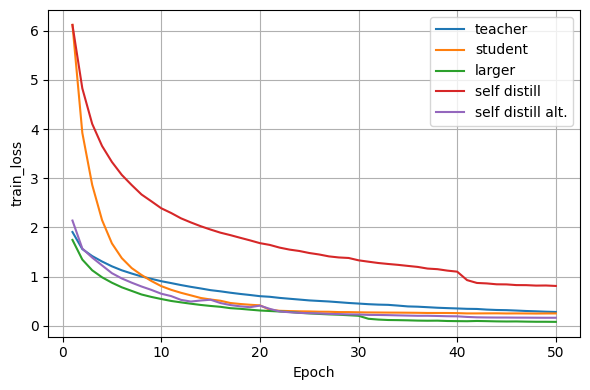

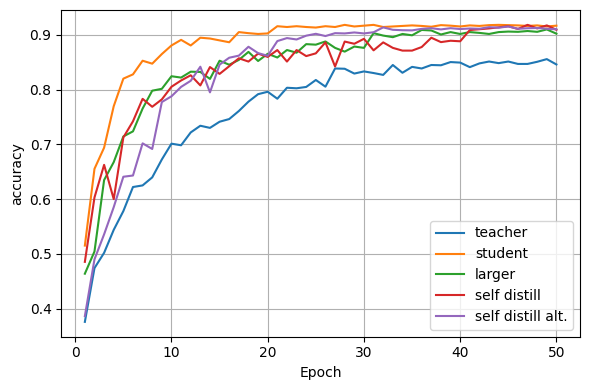

In [26]:
models = ['teacher', 'student', 'larger', 'self distill', 'self distill alt.']
collection = []
with open(os.path.join(project_dir, 'data/states/cifar_resnet34_teacher_1e4.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar_resnet50_t3_a50.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar_resnet50_larger.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar_resnet50_sd_t2_a20.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/cifar_resnet50_sdo_a20.json'), 'r') as f:
    collection.append(json.load(f))

collection[3]['accuracy'] = [i / 100 for i in collection[3]['accuracy']]

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [30]:
del teacher
del larger
del student
del distill_orig
del distill

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

CUDA cache emptied.


# VOC

In [17]:
from data.voc import get_voc_pipeline_test
from models.unet import UNet18, UNet34
from utils.losses import MIoU
from utils.train import evaluate_miou

_, _, test_loader = get_voc_pipeline_test(batch_size=16)
sample_x, sample_y = next(iter(test_loader))

# can plot some images
def show_images():
    pass

Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data


In [18]:
teacher = UNet34(num_classes=21, pretrained=True).to(device)
smaller = UNet18(num_classes=21, pretrained=True).to(device)
student = UNet18(num_classes=21, pretrained=True).to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("UNet34 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("UNet18 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/voc_unet34_teacher.pth'
smaller_path = '../models/final_weights/voc_unet18_smaller.pth'
student_path = '../models/final_weights/voc_unet18_student.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])

teacher_test = evaluate_miou(test_loader, teacher, MIoU(), device)
smaller_test = evaluate_miou(test_loader, smaller, MIoU(), device)
student_test = evaluate_miou(test_loader, student, MIoU(), device)

print(f"Teacher: Val MIoU: {teacher_state['miou']:.4f}")
print(f"Smaller: Val MIoU: {smaller_state['miou']:.4f}")
print(f"Student: Val MIoU: {student_state['miou']:.4f}")

print(f"Teacher: Test MIoU: {teacher_test:.4f}")
print(f"Smaller: Test MIoU: {smaller_test:.4f}")
print(f"Student: Test MIoU: {student_test:.4f}")

UNet34 stats:


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 16 time(s)
Unsupported operator aten::add encountered 4 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
encoder.avgpool, encoder.fc


flops: 98147762176
params: 24233149
UNet18 stats:


Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)
Unsupported operator aten::add encountered 4 time(s)
The following submodules of the model were never called during the trace of the graph. They may be unused, or they were accessed by direct calls to .forward() or via other python methods. In the latter case they will have zeros for statistics, though their statistics will still contribute to their parent calling module.
encoder.avgpool, encoder.fc


flops: 59440627712
params: 14124989
evaluating...: 100%|██████████| 91/91 [02:55<00:00,  1.93s/it]
Teacher: Val MIoU: 0.7478
Smaller: Val MIoU: 0.7431
Student: Val MIoU: 0.7462
Teacher: Test MIoU: 0.7472
Smaller: Test MIoU: 0.7401
Student: Test MIoU: 0.7458


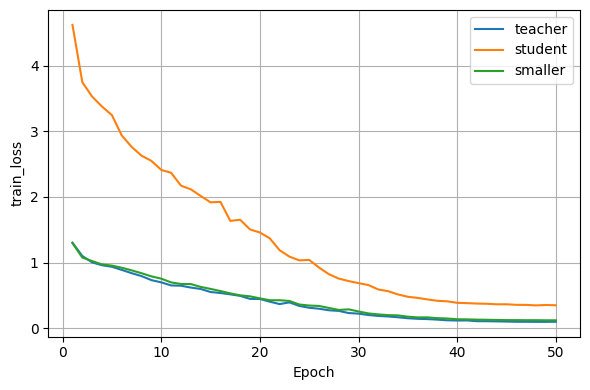

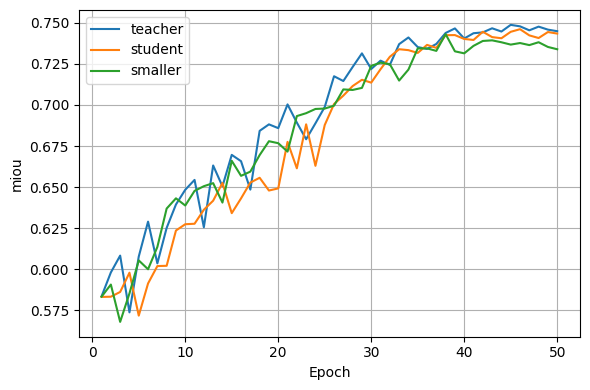

In [19]:
models = ['teacher', 'student', 'smaller']
collection = []
with open(os.path.join(project_dir, 'data/states/voc_unet34_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/voc_unet18_student.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/voc_unet18_smaller.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [38]:
# need reshape (3, H, W), (H, W)?
VOC_COLORMAP = [
    (0, 0, 0),        # background
    (128, 0, 0),      # aeroplane
    (0, 128, 0),      # bicycle
    (128, 128, 0),    # bird
    (0, 0, 128),      # boat
    (128, 0, 128),    # bottle
    (0, 128, 128),    # bus
    (128, 128, 128),  # car
    (64, 0, 0),       # cat
    (192, 0, 0),      # chair
    (64, 128, 0),     # cow
    (192, 128, 0),    # dining table
    (64, 0, 128),     # dog
    (192, 0, 128),    # horse
    (64, 128, 128),   # motorbike
    (192, 128, 128),  # person
    (0, 64, 0),       # potted plant
    (128, 64, 0),     # sheep
    (0, 192, 0),      # sofa
    (128, 192, 0),    # train
    (0, 64, 128)      # tv/monitor
]


def decode_segmap(mask, colormap=VOC_COLORMAP, ignore_index=255):
    h, w = mask.shape
    color_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for label, color in enumerate(colormap):
        color_mask[mask == label] = color

    color_mask[mask == ignore_index] = [0, 0, 0]  # black for ignore
    return color_mask


def show_segmentation(image, pred, target):
    image_np = image.permute(1, 2, 0).cpu().numpy()  # to HWC
    image_np = (image_np * 255).astype(np.uint8)

    pred_mask = decode_segmap(pred.cpu().numpy())
    target_mask = decode_segmap(target.cpu().numpy())

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(image_np)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("Prediction")
    plt.imshow(pred_mask)
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Ground Truth")
    plt.imshow(target_mask)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

def show_segmentation_comparison(image, pred1, pred2, target, model1_name="Model A", model2_name="Model B"):
    """
    Visualize original image, ground truth mask, and predictions from two models.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    image_np = image.permute(1, 2, 0).cpu().numpy()  # (H, W, 3)
    image_np = (image_np * 255).astype(np.uint8)

    pred_mask1 = decode_segmap(pred1.cpu().numpy())   # color mask
    pred_mask2 = decode_segmap(pred2.cpu().numpy())
    target_mask = decode_segmap(target.cpu().numpy())

    plt.figure(figsize=(20, 5))
    plt.subplot(1, 4, 1)
    plt.title("Original")
    plt.imshow(image_np)
    plt.axis('off')

    plt.subplot(1, 4, 2)
    plt.title(model1_name)
    plt.imshow(pred_mask1)
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.title(model2_name)
    plt.imshow(pred_mask2)
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.title("Ground Truth")
    plt.imshow(target_mask)
    plt.axis('off')

    plt.tight_layout()
    plt.show()


In [ ]:
_, _, test_loader = get_voc_pipeline_test(batch_size=1)
sample_x, sample_y = next(iter(test_loader))
print(sample_x.shape, sample_y.shape)

Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
Using downloaded and verified file: /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar
Extracting /home/dodogama/code/project_compression/data/VOCtrainval_11-May-2012.tar to /home/dodogama/code/project_compression/data
torch.Size([1, 3, 256, 256]) torch.Size([1, 256, 256])


In [34]:
# Example tensors
# image: (3, H, W), torch.Tensor
# pred: (H, W), torch.Tensor
# target: (H, W), torch.Tensor
teacher = UNet34(num_classes=21, pretrained=True).to(device)
student = UNet18(num_classes=21, pretrained=True).to(device)
teacher_path = '../models/final_weights/voc_unet34_teacher.pth'
student_path = '../models/final_weights/voc_unet18_student.pth'
teacher_state = torch.load(teacher_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
teacher.load_state_dict(teacher_state['state_dict'])
student.load_state_dict(student_state['state_dict'])

teacher_pred = teacher(sample_x.to(device))
student_pred = student(sample_x.to(device))
print(teacher_pred.shape, student_pred.shape)

torch.Size([1, 21, 256, 256]) torch.Size([1, 21, 256, 256])


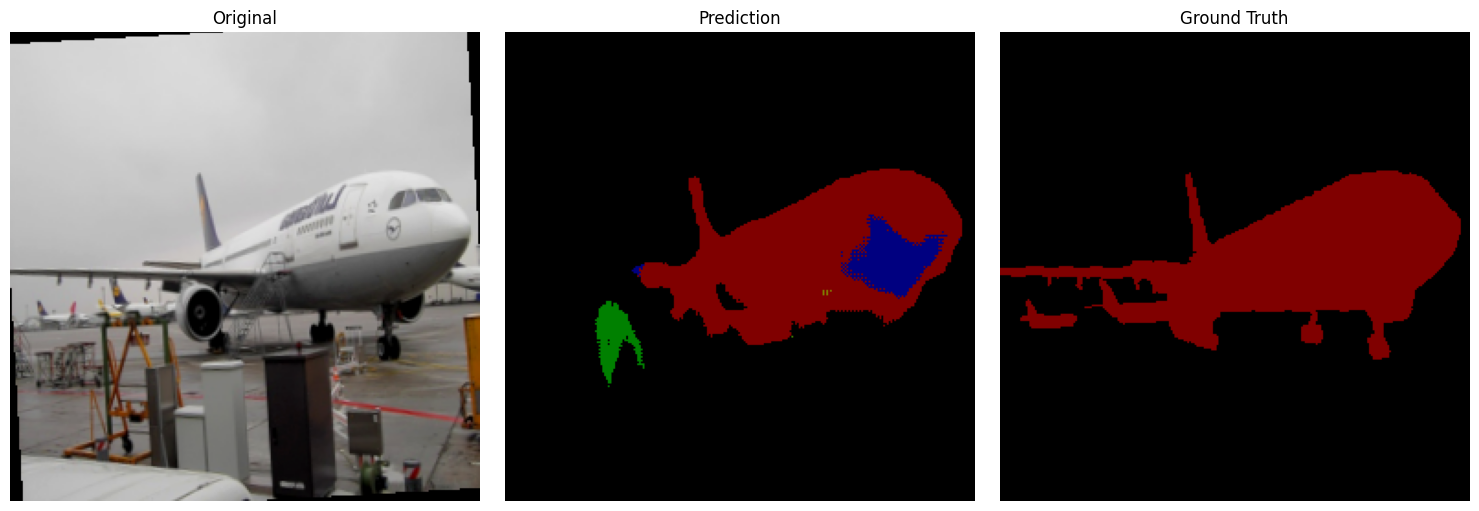

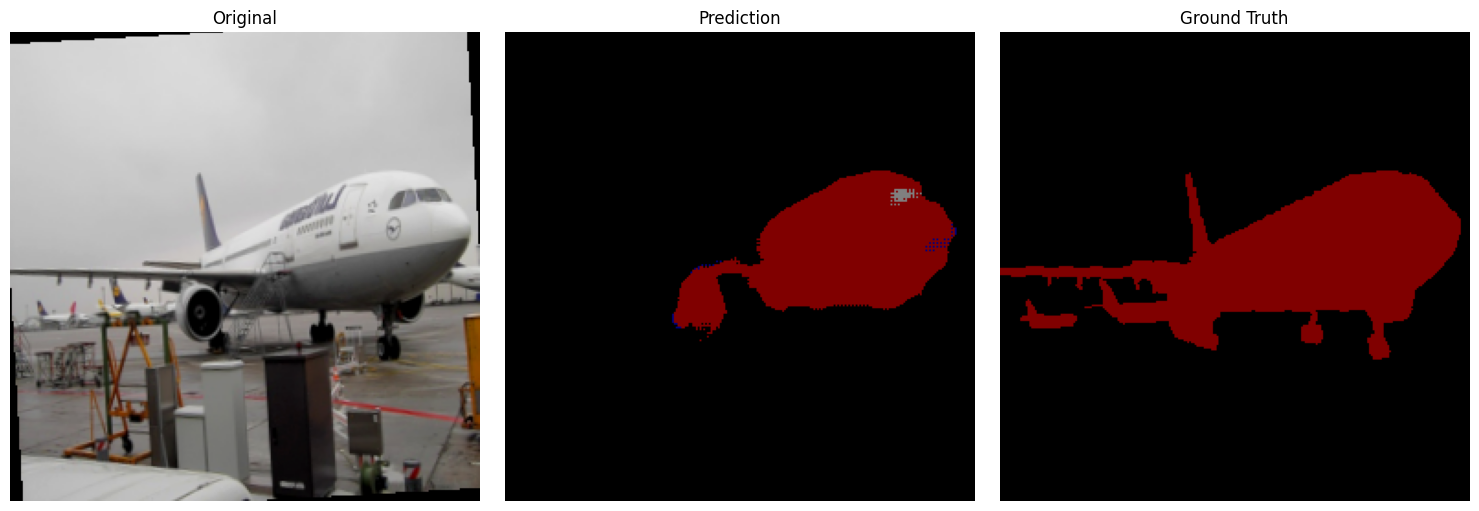

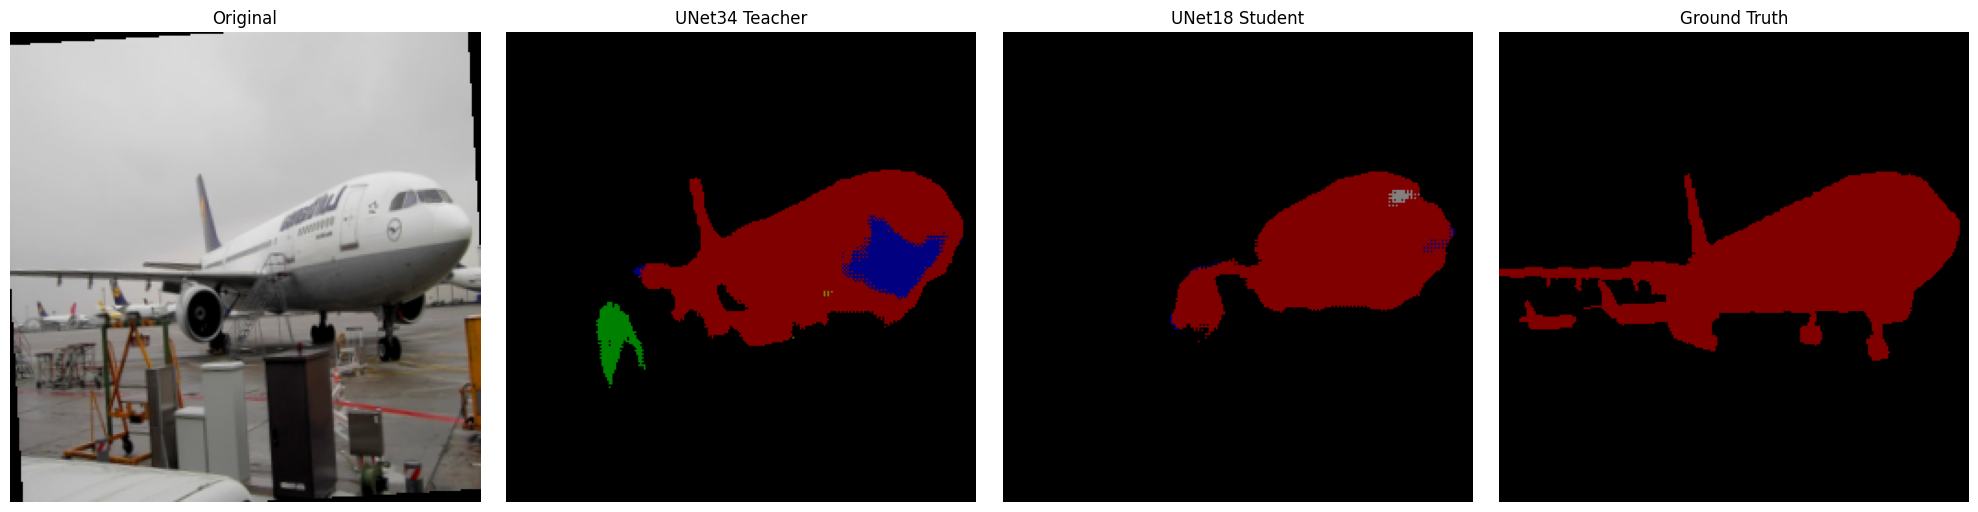

In [39]:
img = sample_x.squeeze(0)
tgt = sample_y.squeeze(0)

teacher_mask = torch.argmax(teacher_pred.squeeze(0), dim=0)
student_mask = torch.argmax(student_pred.squeeze(0), dim=0)

show_segmentation(img, teacher_mask, tgt)
show_segmentation(img, student_mask, tgt)
show_segmentation_comparison(img, teacher_mask, student_mask, tgt, 
                             model1_name="UNet34 Teacher", model2_name="UNet18 Student")

In [22]:
del teacher
del smaller
del student

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

CUDA cache emptied.
